In [11]:
# !pip install mlflow scikit-learn pandas --quiet

import mlflow
import mlflow.sklearn
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, log_loss

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("mnist-mlp")

print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: http://localhost:5000


In [12]:
# Load MNIST
X, y = fetch_openml(
    "mnist_784",
    version=1,
    return_X_y=True,
    as_frame=False
)

# Convert to float and normalize pixels to [0, 1]
X = X.astype("float32") / 255.0
y = y.astype("int64")

# Train / validation / test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.10,
    random_state=42,
    stratify=y_train_full
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (56700, 784)
Validation: (6300, 784)
Test: (7000, 784)


In [13]:
def train_and_log(
    learning_rate=0.001,
    batch_size=64,
    hidden_layer_sizes=(128,),
    epochs=10,
    run_name=None
):

    with mlflow.start_run(run_name=run_name):

        # -------------------------
        # Log hyperparameters
        # -------------------------

        mlflow.log_param("learning_rate", learning_rate)
        mlflow.log_param("batch_size", batch_size)
        mlflow.log_param("hidden_layer_sizes", str(hidden_layer_sizes))
        mlflow.log_param("epochs", epochs)

        # -------------------------
        # Create MLP
        # -------------------------

        model = MLPClassifier(
            hidden_layer_sizes=hidden_layer_sizes,
            learning_rate_init=learning_rate,
            batch_size=batch_size,
            max_iter=1,
            warm_start=True,
            random_state=42
        )

        # -------------------------
        # Train one epoch at a time
        # -------------------------

        for epoch in range(epochs):

            model.fit(X_train, y_train)

            # Training loss
            train_loss = model.loss_

            # Predictions
            train_preds = model.predict(X_train)
            val_preds = model.predict(X_val)

            # Probabilities for validation loss
            val_probs = model.predict_proba(X_val)

            # Accuracy
            train_acc = accuracy_score(y_train, train_preds)
            val_acc = accuracy_score(y_val, val_preds)

            # Validation loss
            val_loss = log_loss(y_val, val_probs)

            # -------------------------
            # Log epoch metrics
            # -------------------------

            mlflow.log_metric(
                "train_loss",
                train_loss,
                step=epoch
            )

            mlflow.log_metric(
                "val_loss",
                val_loss,
                step=epoch
            )

            mlflow.log_metric(
                "train_accuracy",
                train_acc,
                step=epoch
            )

            mlflow.log_metric(
                "val_accuracy",
                val_acc,
                step=epoch
            )

            print(
                f"Epoch {epoch + 1}/{epochs} | "
                f"train_loss={train_loss:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"train_acc={train_acc:.4f} | "
                f"val_acc={val_acc:.4f}"
            )

        # -------------------------
        # Final test accuracy
        # -------------------------

        test_preds = model.predict(X_test)
        test_acc = accuracy_score(y_test, test_preds)

        mlflow.log_metric("test_accuracy", test_acc)

        run_id = mlflow.active_run().info.run_id

        print(
            f"\nRun: {run_id}"
            f"\nFinal test accuracy: {test_acc:.4f}"
        )

        return run_id

In [14]:
run_configs = [
    (0.001, 32),
    (0.001, 64),
    (0.001, 128),
    (0.01, 32),
    (0.01, 64),
    (0.01, 128),
]

run_ids = []

for lr, batch_size in run_configs:

    print("=" * 70)
    print(f"Running: learning_rate={lr}, batch_size={batch_size}")

    run_id = train_and_log(
        learning_rate=lr,
        batch_size=batch_size,
        hidden_layer_sizes=(128,),
        epochs=10,
        run_name=f"mlp-lr{lr}-batch{batch_size}"
    )

    run_ids.append(run_id)

print("\nAll run IDs:")
for run_id in run_ids:
    print(run_id)

Running: learning_rate=0.001, batch_size=32


/home/sreekar/miniconda3/envs/aiops/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoch 1/10 | train_loss=0.2673 | val_loss=0.1509 | train_acc=0.9647 | val_acc=0.9551


/home/sreekar/miniconda3/envs/aiops/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoch 2/10 | train_loss=0.1186 | val_loss=0.1134 | train_acc=0.9777 | val_acc=0.9637


...

Epoch 8/10 | train_loss=0.0705 | val_loss=0.1847 | train_acc=0.9825 | val_acc=0.9635


/home/sreekar/miniconda3/envs/aiops/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoch 9/10 | train_loss=0.0654 | val_loss=0.1836 | train_acc=0.9817 | val_acc=0.9638


/home/sreekar/miniconda3/envs/aiops/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoch 10/10 | train_loss=0.0662 | val_loss=0.2035 | train_acc=0.9835 | val_acc=0.9621

Run: e4b85fc128724b149f5b76e48bdd2cc2
Final test accuracy: 0.9680
🏃 View run mlp-lr0.01-batch128 at: http://localhost:5000/#/experiments/3/runs/e4b85fc128724b149f5b76e48bdd2cc2
🧪 View experiment at: http://localhost:5000/#/experiments/3

All run IDs:
916c3b2cb57d474083791888e2391336
eb4b8eff932c435e96cf413f8d05ad67
f1f9b0eaf22043f0acbfa8fbfe3ab584
5646383d34fa4a9ea3f4a797f25c8e57
37a5576f7b5b40edab592afccbbef187
e4b85fc128724b149f5b76e48bdd2cc2


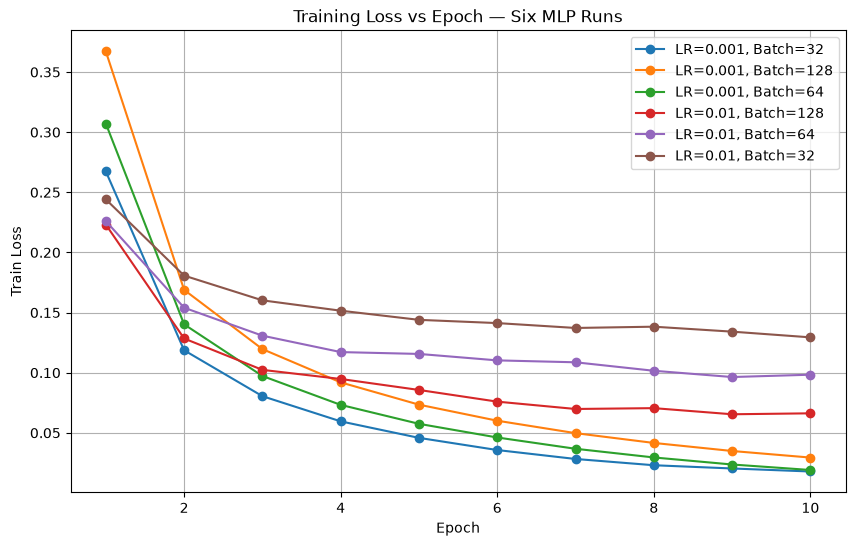

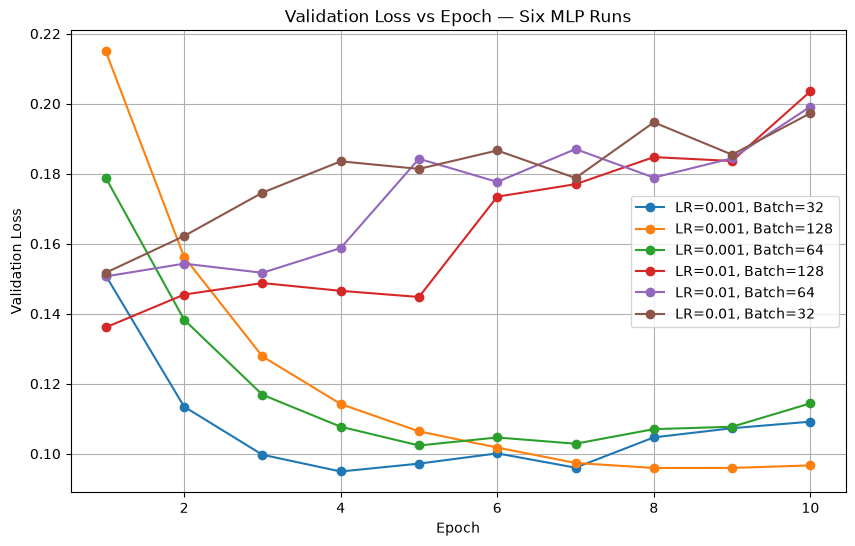

In [19]:
from mlflow.tracking import MlflowClient
import matplotlib.pyplot as plt

client = MlflowClient()

# Use the six runs in runs_df
runs_to_plot = runs_df.head(6)

# -------------------------------------------------
# Plot 1: Training Loss vs Epoch — all six models
# -------------------------------------------------

plt.figure(figsize=(10, 6))

for _, run in runs_to_plot.iterrows():

    run_id = run["run_id"]

    lr = run["params.learning_rate"]
    batch_size = run["params.batch_size"]

    train_loss_history = client.get_metric_history(
        run_id,
        "train_loss"
    )

    epochs = [m.step + 1 for m in train_loss_history]
    train_losses = [m.value for m in train_loss_history]

    label = f"LR={lr}, Batch={batch_size}"

    plt.plot(
        epochs,
        train_losses,
        marker="o",
        label=label
    )

plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss vs Epoch — Six MLP Runs")
plt.legend()
plt.grid(True)
plt.show()


# -------------------------------------------------
# Plot 2: Validation Loss vs Epoch — all six models
# -------------------------------------------------

plt.figure(figsize=(10, 6))

for _, run in runs_to_plot.iterrows():

    run_id = run["run_id"]

    lr = run["params.learning_rate"]
    batch_size = run["params.batch_size"]

    val_loss_history = client.get_metric_history(
        run_id,
        "val_loss"
    )

    epochs = [m.step + 1 for m in val_loss_history]
    val_losses = [m.value for m in val_loss_history]

    label = f"LR={lr}, Batch={batch_size}"

    plt.plot(
        epochs,
        val_losses,
        marker="o",
        label=label
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Epoch — Six MLP Runs")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
import matplotlib.pyplot as plt

runs_df = mlflow.search_runs(
    experiment_names=["mnist-mlp"],
    filter_string="status = 'FINISHED'",
    order_by=["metrics.test_accuracy DESC"]
)

display_cols = [
    "run_id",
    "tags.mlflow.runName",
    "params.learning_rate",
    "params.batch_size",
    "params.hidden_layer_sizes",
    "metrics.test_accuracy"
]

display(
    runs_df[display_cols].head(6)
)

,run_id,tags.mlflow.runName,params.learning_rate,params.batch_size,params.hidden_layer_sizes,metrics.test_accuracy
0,916c3b2cb57d474083791888e2391336,mlp-lr0.001-batch32,0.001,32,"(128,)",0.975714
1,f1f9b0eaf22043f0acbfa8fbfe3ab584,mlp-lr0.001-batch128,0.001,128,"(128,)",0.973714
2,eb4b8eff932c435e96cf413f8d05ad67,mlp-lr0.001-batch64,0.001,64,"(128,)",0.973714
3,e4b85fc128724b149f5b76e48bdd2cc2,mlp-lr0.01-batch128,0.01,128,"(128,)",0.968000
4,37a5576f7b5b40edab592afccbbef187,mlp-lr0.01-batch64,0.01,64,"(128,)",0.964143
5,5646383d34fa4a9ea3f4a797f25c8e57,mlp-lr0.01-batch32,0.01,32,"(128,)",0.956000
